In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
import os
import glob

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (15, 8)

In [76]:
class FilterTester:
    def __init__(self):
        # Edge detection filters
        filters = {
            'Sobel X': torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32),
            'Sobel Y': torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32),
            'Prewitt X': torch.tensor([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=torch.float32),
            'Prewitt Y': torch.tensor([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=torch.float32),
            'Roberts 1': torch.tensor([[1, 0, 0], [0, -1, 0], [0, 0, 0]], dtype=torch.float32),
            'Roberts 2': torch.tensor([[0, 1, 0], [-1, 0, 0], [0, 0, 0]], dtype=torch.float32),
            'Laplacian': torch.tensor([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=torch.float32)
        }
        
        self.filters = {name: f.unsqueeze(0).unsqueeze(0).to(device) for name, f in filters.items()}
        
        # Morphological kernel
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        self.morph_kernel_size = kernel.shape
    
    def adjust_contrast(self, image, contrast=1.0):
        """
        Adjust image contrast
        contrast > 1.0: Increase contrast (more dramatic differences)
        contrast < 1.0: Decrease contrast (flatten differences)
        contrast = 1.0: No change
        """
        # Center around 0.5 (middle gray), apply contrast, then shift back
        return torch.clamp((image - 0.5) * contrast + 0.5, 0.0, 1.0)
        
    def apply_edge_filters(self, image, enhance_dark=False, dark_boost=2.0, contrast=1.0):
        # Apply contrast adjustment first if needed
        if contrast != 1.0:
            image = self.adjust_contrast(image, contrast)
        
        if enhance_dark:
            # Create dark region mask (invert image: dark regions become bright)
            dark_mask = 1.0 - image  # Dark regions have higher values
            
            return {name: torch.abs(F.conv2d(image, filt, padding=1)) * (1.0 + dark_boost * dark_mask)
                    for name, filt in self.filters.items()}
        else:
            return {name: torch.abs(F.conv2d(image, filt, padding=1)) 
                    for name, filt in self.filters.items()}
    
    def morph_closing(self, image):
        dilated = F.max_pool2d(image, self.morph_kernel_size, stride=1, padding=self.morph_kernel_size[0]//2)
        return -F.max_pool2d(-dilated, self.morph_kernel_size, stride=1, padding=self.morph_kernel_size[0]//2)
    
    def morph_opening(self, image):
        eroded = -F.max_pool2d(-image, self.morph_kernel_size, stride=1, padding=self.morph_kernel_size[0]//2)
        return F.max_pool2d(eroded, self.morph_kernel_size, stride=1, padding=self.morph_kernel_size[0]//2)

tester = FilterTester()

In [77]:
def load_image(path, size=(156, 88)):
    img = Image.open(path).convert('L').resize(size)
    arr = np.array(img, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)
    return tensor, arr

def find_images():
    paths = []
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths.extend(glob.glob(f'd:\\mouse_vs_ai_windows\\pics\\**\\{ext}', recursive=True))
    return paths

def create_synthetic_oval():
    img = np.random.normal(0.3, 0.1, (88, 156)).astype(np.float32)
    y, x = np.ogrid[:88, :156]
    oval1 = ((x - 78) / 20) ** 2 + ((y - 44) / 12) ** 2 <= 1
    oval2 = ((x - 39) / 15) ** 2 + ((y - 29) / 8) ** 2 <= 1
    img[oval1] = 0.7
    img[oval2] = 0.8
    img = np.clip(img, 0, 1)
    tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
    return tensor, img

available_images = find_images()
print(f"Found {len(available_images)} images")

Found 6 images


In [78]:
def visualize(original_img, results, title="Filter Results"):
    n = len(results) + 1
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    # Original
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Results
    for i, (name, result) in enumerate(results.items(), 1):
        if i < len(axes):
            result_np = result.squeeze().cpu().numpy()
            cmap = 'plasma' if '+' in name else 'hot'
            axes[i].imshow(result_np, cmap=cmap)
            axes[i].set_title(name, fontsize=9)
            axes[i].axis('off')
    
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def test_image(img_idx_or_path, filters=None, morph=None, enhance_dark=False, dark_boost=2.0, contrast=1.0):
    if isinstance(img_idx_or_path, int):
        if img_idx_or_path >= len(available_images):
            print("Creating synthetic image...")
            img_tensor, img_array = create_synthetic_oval()
            name = "synthetic"
        else:
            path = available_images[img_idx_or_path]
            img_tensor, img_array = load_image(path)
            name = os.path.basename(path)
    else:
        img_tensor, img_array = load_image(img_idx_or_path)
        name = os.path.basename(img_idx_or_path)
    
    # Store original for display
    display_img = img_array.copy()
    
    # Apply contrast adjustment for display if needed
    if contrast != 1.0:
        display_tensor = tester.adjust_contrast(img_tensor, contrast)
        display_img = display_tensor.squeeze().cpu().numpy()
    
    # Apply edge filters with optional enhancements
    edge_results = tester.apply_edge_filters(img_tensor, enhance_dark=enhance_dark, 
                                           dark_boost=dark_boost, contrast=contrast)
    
    # Apply morphological operations if requested
    results = {}
    if filters:
        for f in filters:
            if f in edge_results:
                results[f] = edge_results[f]
                if morph in ['closing', 'both']:
                    results[f + '+Closing'] = tester.morph_closing(edge_results[f])
                if morph in ['opening', 'both']:
                    results[f + '+Opening'] = tester.morph_opening(edge_results[f])
    else:
        results = edge_results
    
    # Build title with enhancements
    title_parts = [f"Results: {name}"]
    if contrast != 1.0:
        title_parts.append(f"Contrast x{contrast}")
    if enhance_dark:
        title_parts.append(f"Dark Enhanced x{dark_boost}")
    title = " | ".join(title_parts)
    
    visualize(display_img, results, title)
    
    # Stats
    for name, result in results.items():
        mean_val = result.mean().item()
        max_val = result.max().item()
        print(f"{name:15}: Mean={mean_val:.3f}, Max={max_val:.3f}")

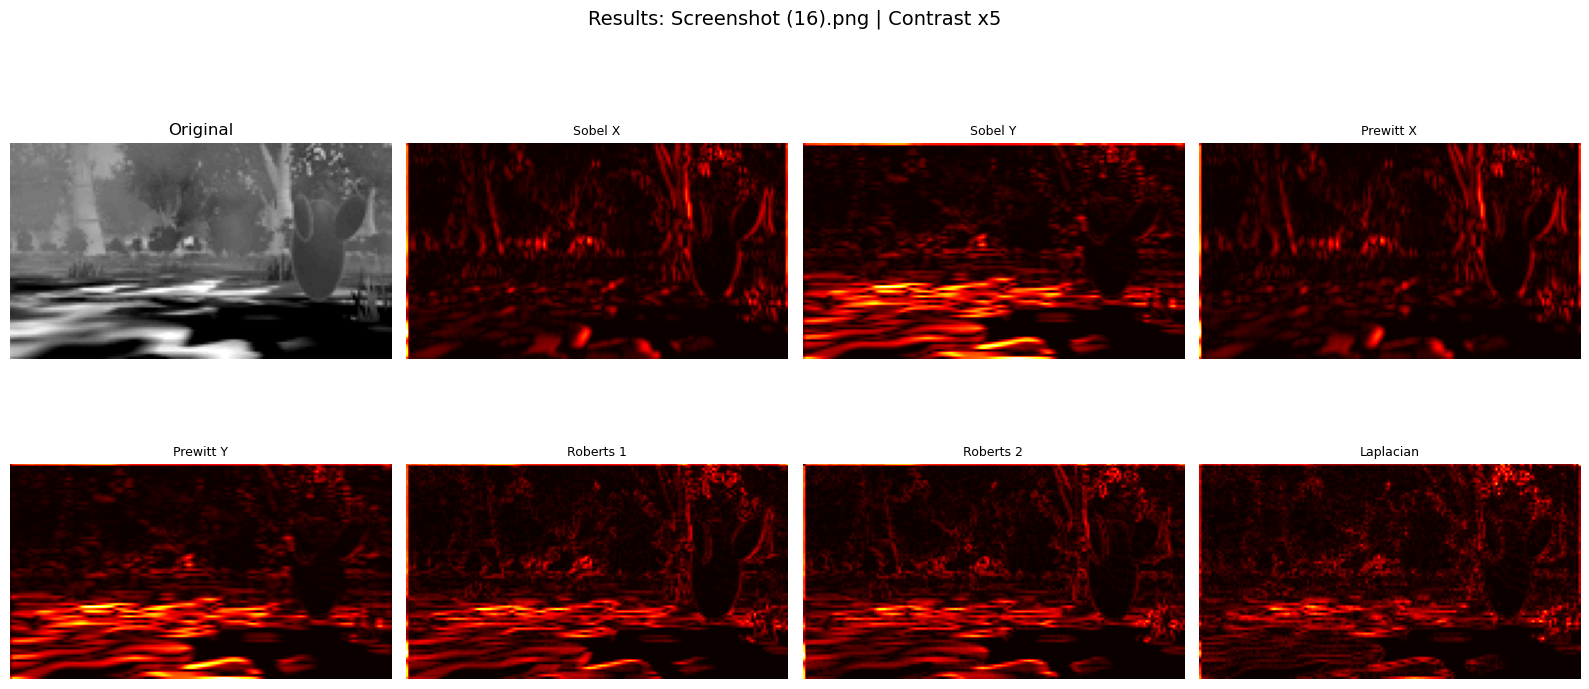

Sobel X        : Mean=0.169, Max=3.588
Sobel Y        : Mean=0.355, Max=4.000
Prewitt X      : Mean=0.124, Max=2.627
Prewitt Y      : Mean=0.264, Max=3.000
Roberts 1      : Mean=0.070, Max=0.961
Roberts 2      : Mean=0.068, Max=0.961
Laplacian      : Mean=0.107, Max=1.725


In [87]:
# Quick tests
test_image(2,contrast=5)  # Test first image with all filters

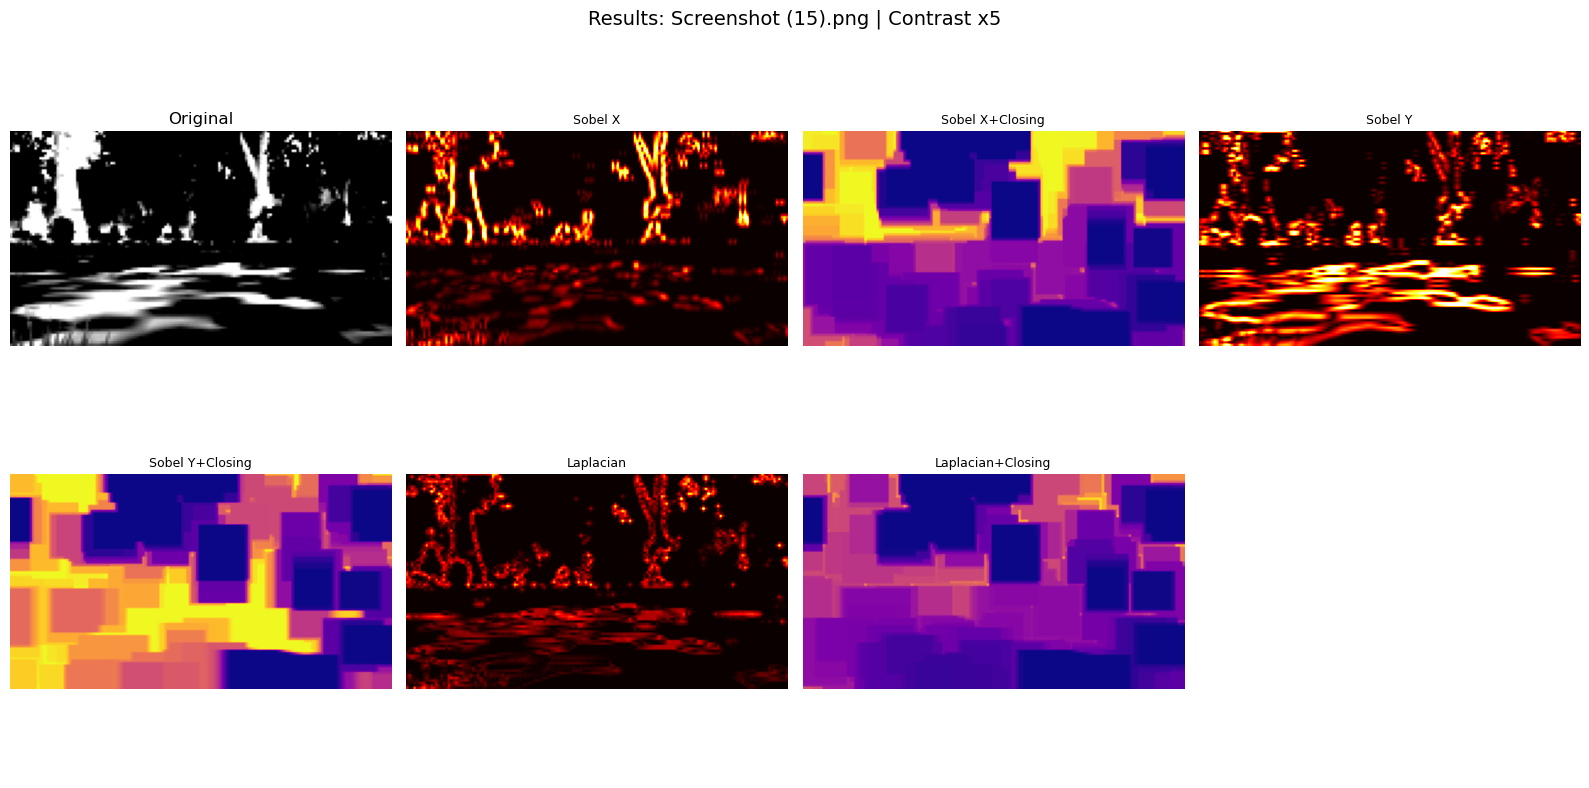

Sobel X        : Mean=0.331, Max=4.000
Sobel X+Closing: Mean=1.180, Max=4.000
Sobel Y        : Mean=0.532, Max=4.000
Sobel Y+Closing: Mean=1.751, Max=4.000
Laplacian      : Mean=0.206, Max=4.000
Laplacian+Closing: Mean=0.839, Max=4.000


In [89]:
# Test with morphological operations
test_image(1,contrast=5, filters=['Sobel X', 'Sobel Y', 'Laplacian'], morph='closing')

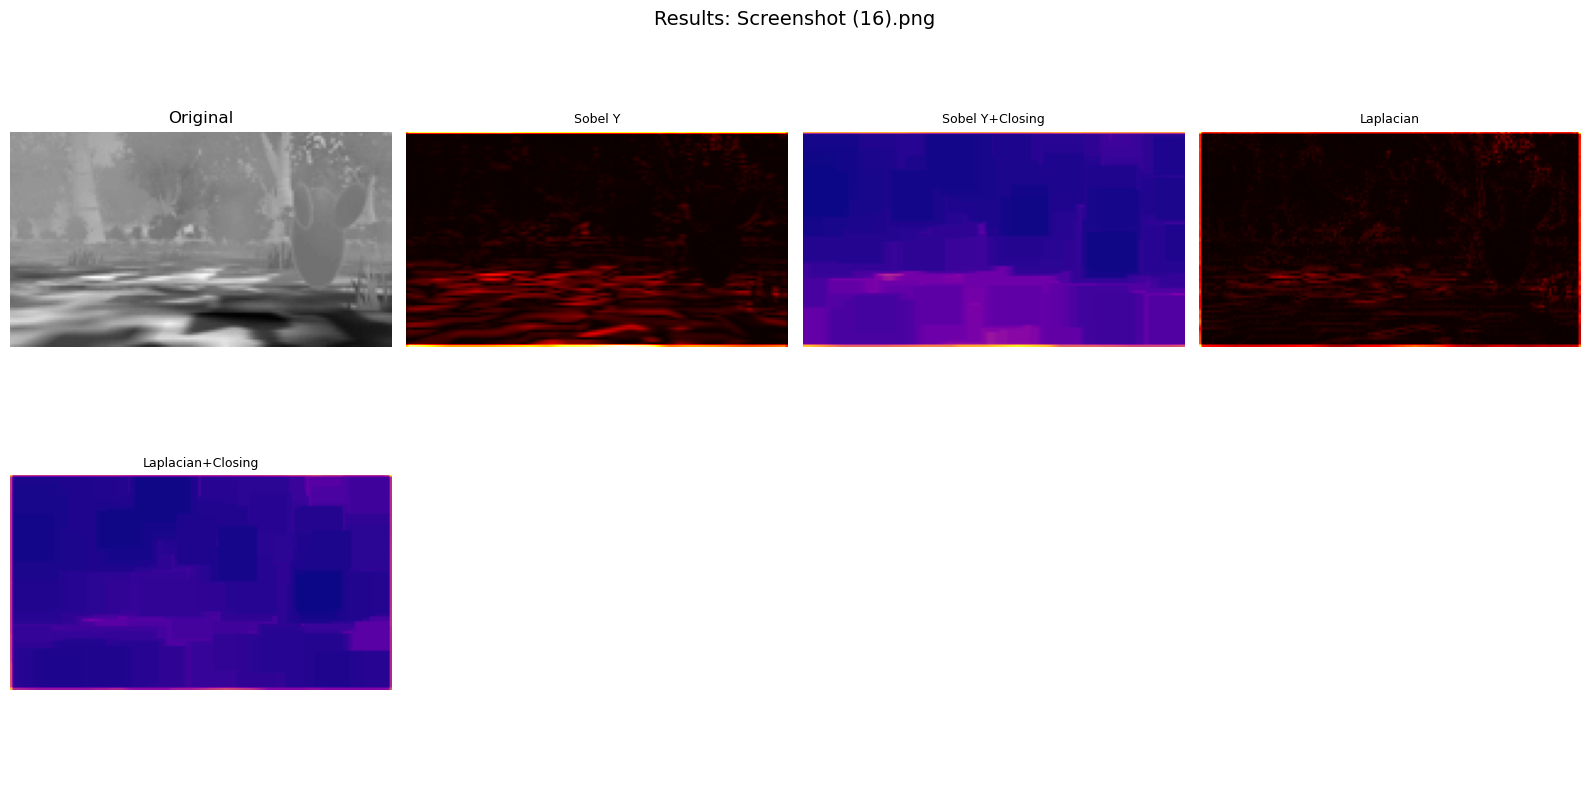

Sobel Y        : Mean=0.119, Max=2.420
Sobel Y+Closing: Mean=0.233, Max=2.420
Laplacian      : Mean=0.036, Max=1.145
Laplacian+Closing: Mean=0.082, Max=1.145


In [72]:
# Test synthetic oval image
test_image(2, filters=['Sobel Y', 'Laplacian'], morph='closing')

=== Normal Edge Detection ===
Creating synthetic image...


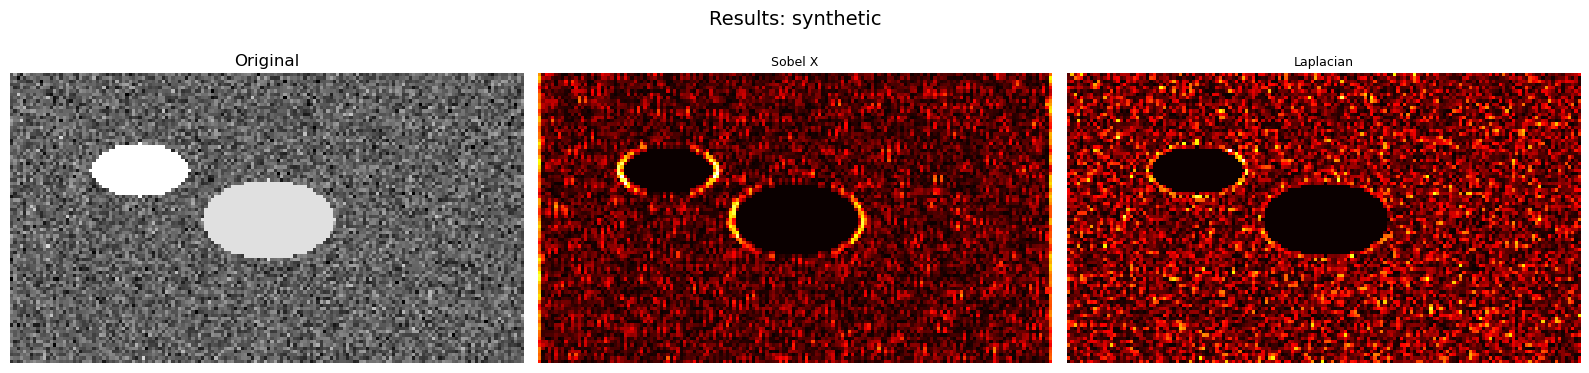

Sobel X        : Mean=0.280, Max=2.256
Laplacian      : Mean=0.345, Max=2.014

=== Enhanced Dark Region Detection ===
Creating synthetic image...


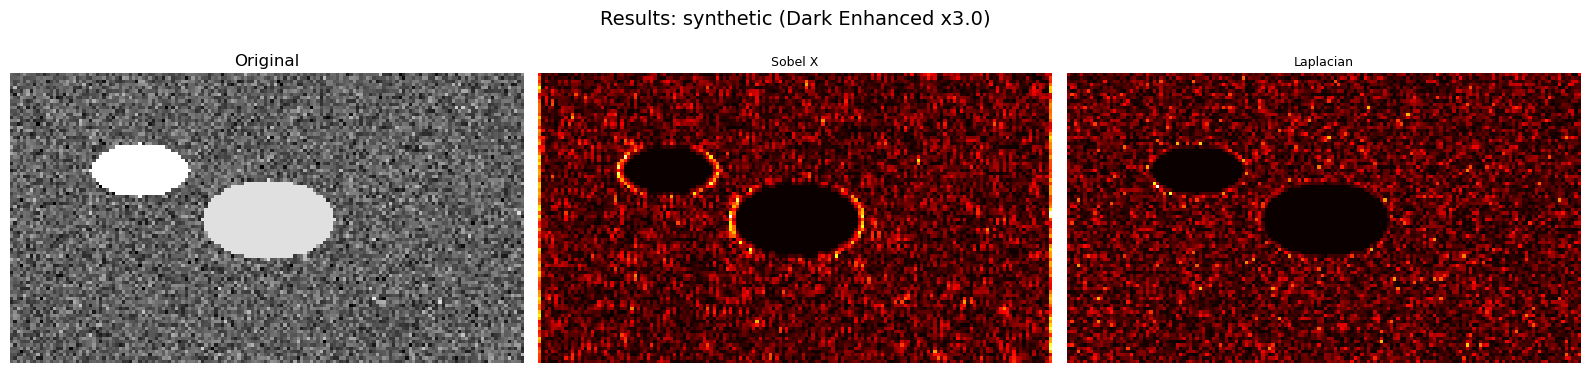

Sobel X        : Mean=0.850, Max=7.040
Laplacian      : Mean=1.058, Max=9.449


In [64]:
# Test dark region enhancement
print("=== Normal Edge Detection ===")
test_image(999, filters=['Sobel X', 'Laplacian'])

print("\n=== Enhanced Dark Region Detection ===")
test_image(999, filters=['Sobel X', 'Laplacian'], enhance_dark=True, dark_boost=3.0)

In [ ]:
# Test contrast adjustment
print("=== Low Contrast (0.5x) ===")
test_image(999, filters=['Sobel X', 'Laplacian'], contrast=0.5)

print("\n=== Normal Contrast (1.0x) ===") 
test_image(999, filters=['Sobel X', 'Laplacian'], contrast=1.0)

print("\n=== High Contrast (2.0x) ===")
test_image(999, filters=['Sobel X', 'Laplacian'], contrast=2.0)

# Edge Detection + Morphological Filter Testing

## Usage:
```python
# Basic edge detection
test_image(0)  # All filters on first image
test_image(999)  # Synthetic oval image

# Morphological operations
test_image(0, filters=['Sobel X', 'Laplacian'], morph='closing')
test_image(0, filters=['Sobel Y'], morph='both')

# Contrast adjustment  
test_image(0, contrast=0.5)   # Decrease contrast (flatten image)
test_image(0, contrast=2.0)   # Increase contrast (sharpen differences)

# Dark region enhancement
test_image(0, enhance_dark=True, dark_boost=3.0)

# Combined enhancements
test_image(0, filters=['Sobel X'], contrast=1.5, enhance_dark=True, dark_boost=2.0)
```

## Available:
- **Edge Filters**: Sobel X/Y, Prewitt X/Y, Roberts 1/2, Laplacian
- **Morphological**: Closing (fills gaps), Opening (removes noise)  
- **Contrast**: Adjust image contrast (0.5=flat, 1.0=normal, 2.0=sharp)
- **Dark Enhancement**: Boost edge detection in dark regions
- **Images**: Auto-detected from workspace + synthetic oval generator